# 1 - Data Import and Exploration

In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r".*datetime\.datetime\.utcnow\(\) is deprecated.*",
    category=DeprecationWarning,
)

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module=r"jupyter_client\..*",
)

In [2]:
from google.colab import drive; drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# read companies final and stocks final from drive
import pandas as pd

df_companies = pd.read_csv("/content/drive/MyDrive/TradingAgent/sp500_companies_top100_transformed.csv")
df_stocks = pd.read_csv("/content/drive/MyDrive/TradingAgent/sp500_stocks_top100_transformed.csv")


In [4]:
df_companies.head()

,Symbol,Exchange,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NVDA,NMS,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,177.39,4311464017920,1.332300e+11,0.732,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.068758
1,AAPL,NMS,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,255.92,3761492983808,1.529020e+11,0.157,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.059987
2,GOOGL,NMS,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,295.77,3577929793536,1.501750e+11,0.180,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.057059
3,GOOG,NMS,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,294.46,3562082664448,1.501750e+11,0.180,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.056807
4,MSFT,NMS,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,373.46,2775695753216,1.752590e+11,0.167,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.044266


In [5]:
with pd.option_context("display.max_columns", None):
    display(df_stocks.head())

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume,return_1d,return_5d,return_20d,ma20_diff,ma50_diff,ma200_diff,volatility_20,rsi_14,range_pct,atr_pct,vol_ratio,vol_z_20
0,2010-10-18,AAPL,9.528233,11.357143,11.392857,11.224643,11.373929,1093010800,0.010357,0.076652,0.122762,0.086516,0.175766,0.295413,0.014371,83.388509,0.017654,0.192268,1.743259,2.324036
1,2010-10-19,AAPL,9.273251,11.053214,11.206071,10.715000,10.835714,1232784000,-0.026761,0.036678,0.090636,0.052814,0.140276,0.258299,0.016114,70.062088,0.052956,0.196959,1.881457,2.385951
2,2010-10-20,AAPL,9.304414,11.090357,11.223214,10.959643,11.035714,721624400,0.003361,0.034617,0.079167,0.052275,0.139814,0.260065,0.015957,70.678833,0.028328,0.197860,1.089993,0.246286
3,2010-10-21,AAPL,9.274151,11.054286,11.240714,10.957143,11.155714,551460000,-0.003253,0.023850,0.071300,0.045204,0.131180,0.253460,0.016038,69.188202,0.030577,0.200071,0.847993,-0.409721
4,2010-10-22,AAPL,9.212724,10.981071,11.072857,10.939286,11.038214,372778000,-0.006623,-0.023099,0.051827,0.035632,0.119133,0.242720,0.016070,66.139095,0.014498,0.202648,0.585690,-1.058509


In [6]:
# first 10 rows in df_companies by highest weight to lowest

df_companies_top_10_by_weight = df_companies.sort_values(by="Weight", ascending=False).head(10)
df_companies_top_10_by_weight

,Symbol,Exchange,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NVDA,NMS,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,177.39,4311464017920,1.332300e+11,0.732,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.068758
1,AAPL,NMS,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,255.92,3761492983808,1.529020e+11,0.157,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.059987
2,GOOGL,NMS,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,295.77,3577929793536,1.501750e+11,0.180,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.057059
3,GOOG,NMS,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,294.46,3562082664448,1.501750e+11,0.180,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.056807
4,MSFT,NMS,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,373.46,2775695753216,1.752590e+11,0.167,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.044266
5,AMZN,NMS,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,209.77,2251864408064,1.457310e+11,0.136,Seattle,WA,United States,1551000.0,"Amazon.com, Inc. engages in the retail sale of...",0.035912
6,AVGO,NMS,Broadcom Inc.,Broadcom Inc.,Technology,Semiconductors,314.55,1491367493632,3.721800e+10,0.295,Palo Alto,CA,United States,20000.0,"Broadcom Inc. designs, develops, and supplies ...",0.023784
7,META,NMS,"Meta Platforms, Inc.","Meta Platforms, Inc.",Communication Services,Internet Content & Information,574.46,1453128548352,1.018920e+11,0.238,Menlo Park,CA,United States,72404.0,"Meta Platforms, Inc. engages in the developmen...",0.023174
8,TSLA,NMS,"Tesla, Inc.","Tesla, Inc.",Consumer Cyclical,Auto Manufacturers,360.59,1353089417216,1.050300e+10,-0.031,Austin,TX,United States,140473.0,"Tesla, Inc. designs, develops, manufactures, l...",0.021579
9,BRK-B,NYQ,Berkshire Hathaway Inc. New,Berkshire Hathaway Inc.,Financial Services,Insurance - Diversified,477.35,1029582356480,1.105940e+11,-0.007,Omaha,NE,United States,396500.0,"Berkshire Hathaway Inc., through its subsidiar...",0.016419


# 2 - Continuous Action Space (Portfolio Weights)

### 2.1 - Environment Definition

In [7]:
!pip install gymnasium

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd


# Gewichtsbildung im kontinuierlichen Aktionsraum:
#   "direct"  -- die Aktion ist direkt das Zielgewicht je Titel (erreicht 0-100%)
#   "softmax" -- Softmax ueber Logits mit festem Kassenlogit (fruehere Version;
#                deckelt bei N=50 ein Einzelgewicht auf 12.5%, die Kasse auf 5.2%)
WEIGHT_MODE = "direct"


class MultiStockTradingEnv(gym.Env):
    """
    Continuous portfolio-weight environment for multi-stock trading.

    The agent outputs one logit per stock. A softmax (with an extra
    cash logit fixed at 0) converts them to portfolio weights that
    sum to 1. Negative logits shift allocation toward cash.

    Action      : Box(-1, 1, shape=(N,)) -- one logit per stock
    Observation : [features (N*F) | portfolio weights (N) | cash ratio (1)]
    Reward      : log(portfolio_value_next / portfolio_value_current)
    Costs       : proportional fee (cost_bps) on every rebalanced dollar
    Episodes    : fixed-length windows starting at random dates
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        df,
        symbols,
        feature_cols,
        initial_cash   = 10_000,
        cost_bps       = 5,
        episode_length = 504, # ~2 trading year per episode
        weight_mode    = None,  # None -> globaler WEIGHT_MODE
    ):
        super().__init__()

        self.symbols        = list(symbols)
        self.n_stocks       = len(self.symbols)
        self.feature_cols   = list(feature_cols)
        self.initial_cash   = float(initial_cash)
        self.cost           = cost_bps / 10_000.0
        self.episode_length = episode_length
        self.weight_mode    = weight_mode or WEIGHT_MODE

        # ---- Build price matrix (T, N) and feature tensor (T, N, F) ----
        df = df[df["Symbol"].isin(self.symbols)].copy()
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values(["Date", "Symbol"])

        price_wide = df.pivot(index="Date", columns="Symbol", values="Adj Close")
        price_wide = price_wide[self.symbols].dropna()
        self.prices = price_wide.to_numpy(dtype=np.float64)
        self.dates  = price_wide.index
        self.T      = len(self.dates)

        feat_list = []
        for col in self.feature_cols:
            fw = df.pivot(index="Date", columns="Symbol", values=col)
            fw = fw.loc[self.dates, self.symbols]
            feat_list.append(fw.to_numpy(dtype=np.float64))
        self.features = np.stack(feat_list, axis=-1)

        # ---- Define action and observation spaces ----
        # Action: one continuous logit per stock (N=50)
        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(self.n_stocks,), dtype=np.float32
        )

        # Observation layout: N*F features + N current weights + 1 cash ratio
        # With N=50 stocks and F=12 features -> obs_dim = 50*12 + 50 + 1 = 651
        obs_dim = self.n_stocks * len(self.feature_cols) + self.n_stocks + 1
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )

    # ------------------------------------------------------------------

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Pick a random start so the agent trains on diverse market regimes
        max_start    = self.T - self.episode_length - 1
        self.t_start = int(self.np_random.integers(0, max_start + 1))
        self.t       = self.t_start
        self.t_end   = self.t_start + self.episode_length

        self.cash            = self.initial_cash
        self.shares          = np.zeros(self.n_stocks, dtype=np.float64)
        self.portfolio_value = self.initial_cash
        self.current_weights = np.zeros(self.n_stocks, dtype=np.float64)

        return self._get_obs(), {}

    # ------------------------------------------------------------------

    def _get_obs(self):
        feat        = self.features[self.t].reshape(-1).astype(np.float32)
        weights_obs = self.current_weights.astype(np.float32)
        pv          = self.cash + np.sum(self.shares * self.prices[self.t])
        cash_ratio  = np.float32(self.cash / (pv + 1e-9))
        return np.concatenate([feat, weights_obs, [cash_ratio]])

    # ------------------------------------------------------------------

    def step(self, action):
        if self.t >= self.t_end:
            return self._get_obs(), 0.0, False, True, self._info_dict(0.0, 0.0)

        prices_t = self.prices[self.t]
        pv_t     = self.cash + np.sum(self.shares * prices_t)

        # ---- Convert actions to target portfolio weights ----
        action = np.asarray(action, dtype=np.float64)

        if self.weight_mode == "direct":
            # The action IS the target weight per stock; a negative component
            # means "no position" and maps to an exact zero. If the requested
            # weights sum to more than 1, scale them down proportionally (no
            # leverage, relative preferences preserved); otherwise the
            # unallocated remainder stays in cash. Reaches exactly 100% in a
            # single stock and exactly 100% cash, matching the allocations the
            # discrete action space can reach.
            w = np.maximum(action, 0.0)
            s = w.sum()
            target_weights = w / s if s > 1.0 else w
        else:
            # Legacy: softmax over the logits with a fixed 0-logit for cash.
            logits     = np.append(action, 0.0)   # last element = cash logit
            logits    -= logits.max()             # numerical stability
            exp_logits = np.exp(logits)
            target_weights = (exp_logits / exp_logits.sum())[:-1]

        # ---- Rebalance: two-phase execution (sells settle before buys) ----
        # Phase 1 liquidates, phase 2 spends at most the cash that is then on
        # hand. This mirrors the two-phase logic of the discrete environment and
        # guarantees the balance can never turn negative, so the no-borrowing
        # assumption holds for the *executed* portfolio and not merely for the
        # target weights.
        #
        # Orders are executed in fractional shares and there is no minimum order
        # size, exactly as in the discrete environment. Both formulations
        # therefore operate under identical execution rules, so the comparison
        # in the evaluation reflects the action-space encoding alone.
        target_values = target_weights * pv_t  # target $ value per stock

        # Each stock is independent, so the whole 50-way rebalance runs as NumPy
        # array ops instead of a Python for-loop (large per-step speed-up).
        delta_value = target_values - self.shares * prices_t   # +buy / -sell
        notional    = np.abs(delta_value)
        tradable    = prices_t > 0
        buy         = tradable & (delta_value > 0)
        sell        = tradable & (delta_value < 0)

        delta_shares = np.zeros(self.n_stocks, dtype=np.float64)

        # ---- Phase 1: sells, capped at the shares actually held ----
        ss = np.minimum(notional[sell] / prices_t[sell], self.shares[sell])
        delta_shares[sell] = -ss
        sell_value = ss * prices_t[sell]
        sell_fee   = sell_value * self.cost
        self.cash += float((sell_value - sell_fee).sum())

        # ---- Phase 2: buys, funded only by the cash available after phase 1 ----
        # The gross amount covers shares plus fee, so the fee is charged on the
        # amount actually invested -- the same basis as the sell side. If the
        # requested buys exceed the available cash, every buy is scaled down by
        # the same factor: the agent's relative preferences between titles are
        # preserved, and no credit is taken up.
        sb        = delta_value[buy] / (prices_t[buy] * (1.0 + self.cost))
        buy_value = sb * prices_t[buy]
        buy_fee   = buy_value * self.cost
        gross     = float((buy_value + buy_fee).sum())
        if gross > self.cash:
            scale     = (self.cash / gross) if (gross > 0.0 and self.cash > 0.0) else 0.0
            sb        = sb * scale
            buy_value = buy_value * scale
            buy_fee   = buy_fee * scale
        delta_shares[buy] = sb
        self.cash -= float((buy_value + buy_fee).sum())

        self.shares = self.shares + delta_shares

        trading_cost    = float(buy_fee.sum() + sell_fee.sum())
        traded_notional = float(buy_value.sum() + sell_value.sum())

        # ---- Move to next trading day ----
        self.t    += 1
        truncated  = (self.t >= self.t_end)

        prices_next = self.prices[self.t]
        pv_next     = self.cash + np.sum(self.shares * prices_next)

        reward = float(np.log(pv_next / (pv_t + 1e-9)))

        self.portfolio_value = pv_next
        self.current_weights = (self.shares * prices_next) / (pv_next + 1e-9)

        return (
            self._get_obs(),
            reward,
            False,
            bool(truncated),
            self._info_dict(trading_cost, traded_notional, target_weights),
        )

    # ------------------------------------------------------------------

    def _info_dict(self, trading_cost, traded_notional, target_weights=None):
        info = {
            "portfolio_value" : float(self.portfolio_value),
            "cash"            : float(self.cash),
            "shares"          : self.shares.copy(),
            "date"            : self.dates[self.t],
            "trading_cost"    : float(trading_cost),
            "traded_notional" : float(traded_notional),
        }
        if target_weights is not None:
            info["target_weights"] = target_weights.copy()
        return info

In [8]:
# ============================================================================
#  Shared configuration for the multi-seed training protocol
# ----------------------------------------------------------------------------
#  Every agent is trained once per seed in SEEDS and evaluated deterministically
#  on the test period. All reported metrics are mean +/- std over these seeds.
# ============================================================================

!pip install stable_baselines3[extra]

import os, random
from copy import deepcopy
import numpy as np
import pandas as pd
import torch

from stable_baselines3 import PPO, SAC, A2C
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback

# Top 50 S&P 500 stocks by market cap (excluding PLTR and GEV due to short history)
symbols = [
    "NVDA", "AAPL", "GOOGL", "GOOG", "MSFT", "AMZN", "AVGO", "META", "TSLA", "BRK-B",
    "WMT",  "LLY",  "JPM",  "XOM",  "JNJ",  "V",    "COST", "MA",   "ORCL", "NFLX",
    "MU",   "CVX",  "ABBV", "AMD",  "BAC",  "CAT",  "PG",   "KO",   "HD",   "CSCO",
    "MRK",  "GE",   "AMAT", "LRCX", "RTX",  "MS",   "GS",  "INTC",  "UNH", "WFC",
    "PM",   "LIN",  "IBM",  "TMUS",  "MCD",  "PEP",  "VZ", "AXP",   "C", "KLAC"
]

# 12 technical features used as observations
FEATURES = [
    "return_1d", "return_5d", "return_20d",
    "ma20_diff", "ma50_diff", "ma200_diff",
    "volatility_20",
    "rsi_14",
    "range_pct", "atr_pct",
    "vol_ratio", "vol_z_20",
]

# Start from 2013-10-16: earliest date where all 50 stocks have complete
# feature data (bottleneck: ABBV IPO 2013-01-02 + 200-day MA warmup)
df_model = df_stocks[
    (df_stocks["Symbol"].isin(symbols)) &
    (df_stocks["Date"] >= "2013-10-16")
].copy()

# Train: 2013-10-16 to 2022-12-31 (~9 years)
# Test:  2023-01-01 to 2025-12-31 (~3 years)
train_df = df_model[df_model["Date"] <= "2022-12-31"].copy()
test_df  = df_model[df_model["Date"] >= "2023-01-01"].copy()

print(f"Symbols  : {len(symbols)}")
print(f"Train    : {train_df['Date'].min()} -> {train_df['Date'].max()}  ({train_df['Date'].nunique()} days)")
print(f"Test     : {test_df['Date'].min()}  -> {test_df['Date'].max()}  ({test_df['Date'].nunique()} days)")

# ---- S&P 500 index series for the index baseline (optional) ----
# Refresh this file with download_sp500_index.py (run on Colab) so it covers the
# full test period. If it is missing, the S&P 500 baseline is silently skipped.
SP500_INDEX_CSV = "/content/drive/MyDrive/TradingAgent/sp500_index.csv"
if os.path.exists(SP500_INDEX_CSV):
    df_index = pd.read_csv(SP500_INDEX_CSV)
    _idx_end = pd.to_datetime(df_index["Date"]).max()
    if _idx_end < pd.Timestamp("2025-12-31"):
        print(f"WARNING: S&P 500 index only covers through {_idx_end.date()}, but the "
              f"test period ends 2025-12-31. Refresh {SP500_INDEX_CSV} via "
              f"download_sp500_index.py for a complete index baseline.")
    else:
        print(f"S&P 500 index loaded ({len(df_index)} rows, through {_idx_end.date()}).")
else:
    df_index = None
    print(f"NOTE: {SP500_INDEX_CSV} not found -> S&P 500 baseline will be skipped.")


# ---- Shared training configuration (identical across all agents) ----
policy_kwargs = dict(net_arch=[512, 512, 256])
#TIMESTEPS     = 3_000_000     # environment steps per agent, per seed
TIMESTEPS     = 1_000_000     # environment steps per agent, per seed
SEEDS         = [0, 1, 2]     # multi-seed protocol: report mean +/- std over these
PROGRESS_EVERY = 100_000      # print a training-progress line every this many timesteps

# ---- Smoke test: validate the full pipeline (train -> eval -> Drive write) in
#      minutes before committing to the real multi-hour run. False for real runs.
SMOKE_TEST = False
if SMOKE_TEST:
    TIMESTEPS      = 100_000
    SEEDS          = [0]
    PROGRESS_EVERY = 50_000
    print(f">>> SMOKE_TEST on: TIMESTEPS={TIMESTEPS:,}, SEEDS={SEEDS}")

# ---- Output directories ----
MODELS_DIR  = "/content/drive/MyDrive/TradingAgent/models"
RESULTS_DIR = "/content/drive/MyDrive/TradingAgent/results"
PLOTS_DIR   = "/content/drive/MyDrive/TradingAgent/plots"
for _d in (MODELS_DIR, RESULTS_DIR, PLOTS_DIR):
    os.makedirs(_d, exist_ok=True)


def set_global_seeds(seed: int):
    """Seed Python, NumPy and PyTorch so a run is reproducible for a given seed.

    Stable-Baselines3 additionally receives ``seed`` via the model constructor
    and ``make_vec_env``; the custom agents (BDQ, REINFORCE) rely on the global
    seeds set here plus an explicitly seeded environment reset.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

class EpisodeReturnLogger(BaseCallback):
    """Log the training episode return at each episode end, with the timestep.

    Used to build the convergence / learning-curve figure that justifies the
    3,000,000-step training budget. It records one (timestep, episode_return)
    pair per finished training episode. This works for both the vectorised
    on-policy agents (PPO, A2C) and the single-env off-policy agent (SAC),
    because ``make_vec_env`` and the SB3 model wrapper both insert a Monitor
    that adds the episode summary (key ``"episode"``) to the step info.

    The episode return is the sum of the per-step log-returns over a training
    episode, i.e. the same reward signal the custom agents (BDQ, REINFORCE)
    log, so all learning curves share one comparable y-axis.
    """
    def __init__(self, total_timesteps=None, progress_every=None):
        super().__init__()
        self.records = []   # list of (timestep, episode_return)
        self.total_timesteps = total_timesteps
        self.progress_every  = progress_every
        self._next_progress  = progress_every

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            ep = info.get("episode")
            if ep is not None:
                self.records.append((int(self.num_timesteps), float(ep["r"])))
        # periodic training-progress line every `progress_every` timesteps
        if self._next_progress is not None and self.num_timesteps >= self._next_progress:
            pct = min(100.0, 100.0 * self.num_timesteps / self.total_timesteps) if self.total_timesteps else 0.0
            print(f"      {self.num_timesteps:>10,} / {self.total_timesteps:,} steps  ({pct:3.0f}%)", flush=True)
            while self._next_progress <= self.num_timesteps:
                self._next_progress += self.progress_every
        return True


Symbols  : 50
Train    : 2013-10-16 -> 2022-12-30  (2319 days)
Test     : 2023-01-03  -> 2025-12-31  (752 days)
S&P 500 index loaded (2773 rows, through 2025-12-31).


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 2.2 - Seeded Training Function & Rollout

In [9]:
def train_continuous(algo: str, seed: int, timesteps: int = None):
    """Train one continuous-action agent (PPO / A2C / SAC) with a fixed seed.

    Hyperparameters are identical to the single-run setup; the only addition is
    deterministic seeding, so that the spread across seeds reflects optimisation
    noise rather than a single lucky (or unlucky) initialisation.

    Returns (model, learning_curve), where learning_curve is a list of
    (timestep, episode_return) pairs collected during training.
    """
    timesteps = TIMESTEPS if timesteps is None else timesteps
    set_global_seeds(seed)

    if algo in ("PPO", "A2C"):
        env = make_vec_env(
            lambda: MultiStockTradingEnv(train_df, symbols, FEATURES),
            n_envs=4, seed=seed,
        )
    else:  # SAC: off-policy, single environment
        env = MultiStockTradingEnv(train_df, symbols, FEATURES)

    if algo == "PPO":
        model = PPO(
            "MlpPolicy", env, verbose=0, seed=seed, device="cpu",
            policy_kwargs=deepcopy(policy_kwargs), learning_rate=1e-4,
            clip_range=0.2, ent_coef=0.05,
        )
    elif algo == "A2C":
        model = A2C(
            "MlpPolicy", env, verbose=0, seed=seed, device="cpu",
            policy_kwargs=deepcopy(policy_kwargs), learning_rate=1e-4,
            ent_coef=0.05, n_steps=10,
        )
    elif algo == "SAC":
        model = SAC(
            "MlpPolicy", env, verbose=0, seed=seed,
            policy_kwargs=deepcopy(policy_kwargs), learning_rate=1e-4,
            learning_starts=5000, batch_size=512, tau=0.005, ent_coef="auto",
        )
    else:
        raise ValueError(f"Unknown continuous algo: {algo}")

    logger = EpisodeReturnLogger(total_timesteps=timesteps, progress_every=PROGRESS_EVERY)
    model.learn(total_timesteps=timesteps, callback=logger)
    return model, logger.records


In [10]:
import numpy as np
import pandas as pd

def rollout(model, df, symbols, feature_cols, initial_cash=10_000, cost_bps=5):
    """
    Evaluate a trained continuous model on the full test set (no random start).
    Returns a DataFrame with daily portfolio values.
    """
    env = MultiStockTradingEnv(
        df, symbols, feature_cols,
        initial_cash=initial_cash,
        cost_bps=cost_bps,
        episode_length=len(df["Date"].unique()) - 1,
    )

    obs, _ = env.reset()
    # Override random start: run from the first day to the last
    env.t       = 0
    env.t_start = 0
    env.t_end   = env.T - 1
    obs = env._get_obs()

    records = []
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        records.append({
            "date"            : info["date"],
            "portfolio_value" : info["portfolio_value"],
            "cash"            : info["cash"],
            "shares"          : info["shares"],
            "target_weights"  : info.get("target_weights", np.zeros(len(symbols))),
        })

    df_hist = pd.DataFrame(records)
    df_hist["date"] = pd.to_datetime(df_hist["date"])
    return df_hist


In [11]:
import numpy as np
import pandas as pd


def compute_metrics_raw(df_hist, initial_cash=10_000, trading_days=252):
    """Standard financial performance metrics as raw floats (for aggregation)."""
    # Prepend initial capital so metrics cover the full investment period
    pv      = np.concatenate([[initial_cash], df_hist["portfolio_value"].values])
    returns = np.diff(pv) / pv[:-1]

    cumulative_return = (pv[-1] / pv[0]) - 1
    n_periods         = len(returns)
    annualized_return = (1 + cumulative_return) ** (trading_days / n_periods) - 1
    volatility        = returns.std() * np.sqrt(trading_days)
    sharpe            = (returns.mean() / (returns.std() + 1e-9)) * np.sqrt(trading_days)

    # Max drawdown: largest peak-to-trough decline
    peak     = np.maximum.accumulate(pv)
    drawdown = (pv - peak) / (peak + 1e-9)
    max_dd   = drawdown.min()

    calmar = annualized_return / (abs(max_dd) + 1e-9)

    return {
        "cumulative_return": float(cumulative_return),
        "annualized_return": float(annualized_return),
        "volatility":        float(volatility),
        "sharpe":            float(sharpe),
        "max_drawdown":      float(max_dd),
        "calmar":            float(calmar),
    }


def compute_metrics(df_hist, initial_cash=10_000, trading_days=252):
    """Same metrics as compute_metrics_raw, formatted as strings for display."""
    m = compute_metrics_raw(df_hist, initial_cash, trading_days)
    return {
        "Cumulative Return": f"{m['cumulative_return'] * 100:.2f}%",
        "Annualized Return": f"{m['annualized_return'] * 100:.2f}%",
        "Volatility":        f"{m['volatility'] * 100:.2f}%",
        "Sharpe Ratio":      f"{m['sharpe']:.3f}",
        "Max Drawdown":      f"{m['max_drawdown'] * 100:.2f}%",
        "Calmar Ratio":      f"{m['calmar']:.3f}",
    }


def compute_trading_behavior(df_hist, df, symbols):
    """Average daily turnover and effective number of held positions (for FF2).

    Both quantities are reconstructed uniformly from the recorded daily share
    holdings, so they are comparable across all agents and the Buy & Hold
    baseline. They match the definitions in the evaluation chapter:

        Turnover_t  = (sum_i |Delta notional_{t,i}|) / V_t,
                      averaged over t >= 1 (the initial deployment on day 0 is
                      not a rebalancing and is therefore excluded);
        N_eff_t     = 1 / sum_i wn_{t,i}^2, the inverse Herfindahl-Hirschman
                      index of the renormalised equity weights wn = w / sum(w),
                      averaged over the days on which equity is held;
        cash_only    = share of days with no equity position at all.

    Requires df_hist to carry a per-row 'shares' array (the rollouts and the
    Buy & Hold baseline provide this). Returns NaNs otherwise.
    """
    if "shares" not in df_hist.columns:
        return {"turnover": float("nan"), "eff_positions": float("nan"),
                "cash_only_share": float("nan")}

    # Price matrix aligned to the rollout's dates
    prices = (
        df[df["Symbol"].isin(symbols)]
        .pivot(index="Date", columns="Symbol", values="Adj Close")[symbols]
    )
    prices.index = pd.to_datetime(prices.index)
    dates = pd.to_datetime(df_hist["date"])
    P = prices.reindex(dates).to_numpy(dtype=float)          # (T, N)

    S = np.vstack(df_hist["shares"].to_numpy()).astype(float)   # (T, N)
    V = df_hist["portfolio_value"].to_numpy(dtype=float)        # (T,)

    # Diversification of the INVESTED capital: inverse HHI of the equity
    # weights, renormalised to sum to one. Cash is deliberately left out and
    # reported separately as cash_only_share, so this figure answers "how
    # broadly does the agent spread what it invests" without mixing in "how
    # much does it invest" -- the two must stay separable to attribute an
    # action-space effect to either one. Bounded by [1, N].
    # Days with no equity at all have no defined diversification and are
    # excluded from the mean rather than counted as maximally concentrated.
    w_stocks = (S * P) / (V[:, None] + 1e-9)
    invested = w_stocks.sum(axis=1)
    held     = invested > 1e-8
    if held.any():
        w_norm = w_stocks[held] / invested[held][:, None]
        hhi    = np.sum(w_norm * w_norm, axis=1)
        eff_positions = float(np.mean(1.0 / hhi))
    else:
        eff_positions = float("nan")
    # Share of test days on which the agent held no equity position at all.
    cash_only_share = float(np.mean(~held))

    # Turnover: day-to-day change in position notional, relative to V
    traded     = np.abs(np.diff(S, axis=0)) * P[1:]         # (T-1, N)
    turnover_t = traded.sum(axis=1) / (V[1:] + 1e-9)
    turnover   = float(np.mean(turnover_t))

    return {"turnover": turnover, "eff_positions": eff_positions,
            "cash_only_share": cash_only_share}


In [12]:
def buy_and_hold_baseline(df, symbols, initial_cash=10_000):
    """Equal-weight buy-and-hold: invest equally on day 1, never rebalance."""
    prices = (
        df[df["Symbol"].isin(symbols)]
        .pivot(index="Date", columns="Symbol", values="Adj Close")
        [symbols].dropna()
    )
    first_prices   = prices.iloc[0]
    cash_per_stock = initial_cash / len(symbols)
    shares         = cash_per_stock / first_prices

    portfolio_values = (prices * shares).sum(axis=1)
    out = pd.DataFrame({"date": portfolio_values.index, "portfolio_value": portfolio_values.values})

    # Constant share holdings each day -> enables a uniform turnover / concentration
    # computation (turnover is ~0 after the initial purchase, by construction).
    shares_arr = shares[symbols].to_numpy(dtype=float)
    out["shares"] = [shares_arr.copy() for _ in range(len(out))]
    return out


def sp500_index_baseline(df_index, initial_cash=10_000):
    """Normalize S&P 500 index to start at initial_cash for comparison."""
    df = df_index[
        (df_index["Date"] >= test_df["Date"].min()) &
        (df_index["Date"] <= test_df["Date"].max())
    ].copy().sort_values("Date")
    df["portfolio_value"] = initial_cash * (df["S&P500"] / df["S&P500"].iloc[0])
    return df[["Date", "portfolio_value"]].rename(columns={"Date": "date"})


### 2.3 - Metrics & Plotting Helpers

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_portfolio_curves(histories: dict, title="Portfolio Value - Test Period"):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})
    colors = {"PPO": "#2196F3", "A2C": "#FF9800", "SAC": "#4CAF50", "Buy & Hold": "#9E9E9E"}

    # Top panel: portfolio value over time
    ax = axes[0]
    for name, df_h in histories.items():
        dates = pd.to_datetime(df_h["date"])
        ax.plot(dates, df_h["portfolio_value"],
                label=name, color=colors.get(name), linewidth=1.8)
    ax.set_ylabel("Portfolio Value ($)")
    ax.set_title(title)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(alpha=0.3)

    # Bottom panel: drawdown from running peak
    ax2 = axes[1]
    for name, df_h in histories.items():
        dates = pd.to_datetime(df_h["date"])
        pv    = df_h["portfolio_value"].values
        peak  = np.maximum.accumulate(pv)
        dd    = (pv - peak) / (peak + 1e-9) * 100
        ax2.plot(dates, dd, label=name, color=colors.get(name), linewidth=1.2)
    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Date")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    ax2.grid(alpha=0.3)
    ax2.axhline(0, color="black", linewidth=0.8)

    plt.tight_layout()
    plt.savefig("evaluation_results.png", dpi=150, bbox_inches="tight")
    plt.show()


# 3 - Discrete Action Space (Buy / Hold / Sell)

In [15]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd


class DiscreteMultiStockTradingEnv(gym.Env):
    """
    Discrete buy/hold/sell environment for multi-stock trading.

    Each stock gets one of three actions per step:
      0 = Sell  (liquidate entire position in that stock)
      1 = Hold  (do nothing)
      2 = Buy   (invest an equal share of available cash)

    Execution order: all sells happen first, then all buys. This
    lets the agent reinvest proceeds from sells in the same step.

    Action      : MultiDiscrete([3] * N)
    Observation : [features (N*F) | portfolio weights (N) | cash ratio (1)]
    Reward      : log(portfolio_value_next / portfolio_value_current)
    Costs       : proportional fee (cost_bps) on every traded dollar
    Episodes    : fixed-length windows starting at random dates
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        df,
        symbols,
        feature_cols,
        initial_cash   = 10_000,
        cost_bps       = 5,
        episode_length = 504,
    ):
        super().__init__()

        self.symbols        = list(symbols)
        self.n_stocks       = len(self.symbols)
        self.feature_cols   = list(feature_cols)
        self.initial_cash   = float(initial_cash)
        self.cost           = cost_bps / 10_000.0
        self.episode_length = episode_length

        # ---- Build price matrix and feature tensor (same as continuous env) ----
        df = df[df["Symbol"].isin(self.symbols)].copy()
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values(["Date", "Symbol"])

        price_wide = df.pivot(index="Date", columns="Symbol", values="Adj Close")
        price_wide = price_wide[self.symbols].dropna()
        self.prices = price_wide.to_numpy(dtype=np.float64)
        self.dates  = price_wide.index
        self.T      = len(self.dates)

        feat_list = []
        for col in self.feature_cols:
            fw = df.pivot(index="Date", columns="Symbol", values=col)
            fw = fw.loc[self.dates, self.symbols]
            feat_list.append(fw.to_numpy(dtype=np.float64))
        self.features = np.stack(feat_list, axis=-1)

        # ---- Define action and observation spaces ----
        # Action: 3 discrete choices (Sell/Hold/Buy) per stock -> 3^N joint space
        self.action_space = spaces.MultiDiscrete([3] * self.n_stocks)

        # Observation layout: N*F features + N current weights + 1 cash ratio
        # With N=50 stocks and F=12 features -> obs_dim = 50*12 + 50 + 1 = 651
        obs_dim = self.n_stocks * len(self.feature_cols) + self.n_stocks + 1
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )

    # ------------------------------------------------------------------

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        max_start    = self.T - self.episode_length - 1
        self.t_start = int(self.np_random.integers(0, max_start + 1))
        self.t       = self.t_start
        self.t_end   = self.t_start + self.episode_length

        self.cash            = self.initial_cash
        self.shares          = np.zeros(self.n_stocks, dtype=np.float64)
        self.portfolio_value = self.initial_cash
        self.current_weights = np.zeros(self.n_stocks, dtype=np.float64)

        return self._get_obs(), {}

    # ------------------------------------------------------------------

    def _get_obs(self):
        feat        = self.features[self.t].reshape(-1).astype(np.float32)
        weights_obs = self.current_weights.astype(np.float32)
        pv          = self.cash + np.sum(self.shares * self.prices[self.t])
        cash_ratio  = np.float32(self.cash / (pv + 1e-9))
        return np.concatenate([feat, weights_obs, [cash_ratio]])

    # ------------------------------------------------------------------

    def step(self, action):
        if self.t >= self.t_end:
            return self._get_obs(), 0.0, False, True, self._info_dict()

        prices_t = self.prices[self.t]
        pv_t     = self.cash + np.sum(self.shares * prices_t)

        action = np.asarray(action, dtype=np.int32)

        # ---- Phase 1: execute all SELL orders (action=0), vectorised ----
        sell_mask  = (action == 0) & (self.shares > 0)
        sell_value = self.shares[sell_mask] * prices_t[sell_mask]
        self.cash += float((sell_value * (1.0 - self.cost)).sum())
        self.shares[sell_mask] = 0.0

        # ---- Phase 2: execute all BUY orders (action=2), vectorised ----
        # Cash is split equally among every buy signal (incl. any with price<=0,
        # which is then skipped), matching the original per-stock logic. For a
        # valid buy, investable + fee == cash_per_stock, so cash drops by
        # n_valid * cash_per_stock.
        n_buy = int((action == 2).sum())
        if n_buy > 0 and self.cash > 0:
            cash_per_stock = self.cash / n_buy
            investable     = cash_per_stock / (1.0 + self.cost)
            buy_mask       = (action == 2) & (prices_t > 0)
            self.shares[buy_mask] += investable / prices_t[buy_mask]
            self.cash -= int(buy_mask.sum()) * cash_per_stock
            self.cash = max(self.cash, 0.0)

        # ---- Move to next trading day ----
        self.t    += 1
        truncated  = (self.t >= self.t_end)

        prices_next = self.prices[self.t]
        pv_next     = self.cash + np.sum(self.shares * prices_next)

        reward = float(np.log(pv_next / (pv_t + 1e-9)))

        self.portfolio_value = pv_next
        self.current_weights = (self.shares * prices_next) / (pv_next + 1e-9)

        return (
            self._get_obs(),
            reward,
            False,
            bool(truncated),
            self._info_dict(),
        )

    # ------------------------------------------------------------------

    def _info_dict(self):
        return {
            "portfolio_value" : float(self.portfolio_value),
            "cash"            : float(self.cash),
            "shares"          : self.shares.copy(),
            "date"            : self.dates[self.t],
        }

## 3.1 - Training & Loading (PPO / A2C)

In [16]:
def train_discrete_sb3(algo: str, seed: int, timesteps: int = None):
    """Train one discrete-action SB3 agent (PPO / A2C) with a fixed seed.

    Same hyperparameters as the continuous variants; only the environment
    (discrete buy/hold/sell) and the resulting action distribution differ.

    Returns (model, learning_curve), where learning_curve is a list of
    (timestep, episode_return) pairs collected during training.
    """
    timesteps = TIMESTEPS if timesteps is None else timesteps
    set_global_seeds(seed)

    env = make_vec_env(
        lambda: DiscreteMultiStockTradingEnv(train_df, symbols, FEATURES),
        n_envs=4, seed=seed,
    )

    if algo == "PPO":
        model = PPO(
            "MlpPolicy", env, verbose=0, seed=seed, device="cpu",
            policy_kwargs=deepcopy(policy_kwargs), learning_rate=1e-4,
            clip_range=0.2, ent_coef=0.05,
        )
    elif algo == "A2C":
        model = A2C(
            "MlpPolicy", env, verbose=0, seed=seed, device="cpu",
            policy_kwargs=deepcopy(policy_kwargs), learning_rate=1e-4,
            ent_coef=0.05, n_steps=10,
        )
    else:
        raise ValueError(f"Unknown discrete SB3 algo: {algo}")

    logger = EpisodeReturnLogger(total_timesteps=timesteps, progress_every=PROGRESS_EVERY)
    model.learn(total_timesteps=timesteps, callback=logger)
    return model, logger.records


## 3.2 - Branching DQN (BDQ)

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque


class BranchingQNetwork(nn.Module):
    """
    Branching Dueling DQN (Tavakoli et al., AAAI 2018).

    Instead of one Q-head over a combinatorial action space (3^50),
    uses a shared feature extractor with N independent Q-heads
    (one per stock), each outputting 3 Q-values (Sell / Hold / Buy).
    A shared value stream plus per-branch advantage streams form
    a dueling architecture: Q = V + (A - mean(A)).
    """
    def __init__(self, obs_dim, n_branches, n_actions_per_branch=3,
                 hidden_sizes=[512, 512, 256]):
        super().__init__()

        # Shared feature extractor (all branches see the same representation)
        layers = []
        prev = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        self.shared = nn.Sequential(*layers)

        # Single value head V(s)
        self.value_head = nn.Linear(prev, 1)

        # One advantage head A_i(s, a) per stock
        self.branch_heads = nn.ModuleList([
            nn.Linear(prev, n_actions_per_branch)
            for _ in range(n_branches)
        ])
        self.n_branches = n_branches

    def forward(self, x):
        """Returns Q-values: list of N tensors, each (batch, 3)."""
        features = self.shared(x)
        value = self.value_head(features)

        branch_q = []
        for head in self.branch_heads:
            adv = head(features)
            adv = adv - adv.mean(dim=1, keepdim=True)
            branch_q.append(value + adv)

        return branch_q


class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, obs, action, reward, next_obs, done):
        self.buffer.append((obs, action, reward, next_obs, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, act, rew, next_obs, done = zip(*batch)
        return (
            np.array(obs, dtype=np.float32),
            np.array(act, dtype=np.int64),
            np.array(rew, dtype=np.float32),
            np.array(next_obs, dtype=np.float32),
            np.array(done, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


def train_bdq(env_fn, obs_dim, n_branches, total_timesteps=3_000_000, seed=None,
              lr=1e-4, gamma=0.99, batch_size=512, buffer_size=100_000,
              learning_starts=5000, target_update_interval=1000, train_freq=4,
              exploration_fraction=0.2, exploration_final_eps=0.02,
              print_every=50):
    """Train a Branching DQN agent with epsilon-greedy exploration.

    Returns (q_net, learning_curve), where learning_curve is a list of
    (timestep, episode_return) pairs (episode_return = sum of log-returns).
    """
    if seed is not None:
        set_global_seeds(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    q_net      = BranchingQNetwork(obs_dim, n_branches).to(device)
    target_net = BranchingQNetwork(obs_dim, n_branches).to(device)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    replay    = ReplayBuffer(buffer_size)
    env       = env_fn()

    steps_done       = 0
    episode_count    = 0
    reward_history   = []
    learning_curve   = []     # (timestep, episode_return)
    ep_return        = 0.0    # running sum of rewards in the current episode
    exploration_steps = int(total_timesteps * exploration_fraction)
    next_progress     = PROGRESS_EVERY

    if seed is not None:
        env.action_space.seed(seed)
    obs, _ = env.reset(seed=seed)

    while steps_done < total_timesteps:
        # Linear epsilon decay: 1.0 -> exploration_final_eps
        if steps_done < exploration_steps:
            eps = 1.0 - (1.0 - exploration_final_eps) * (steps_done / exploration_steps)
        else:
            eps = exploration_final_eps

        # Epsilon-greedy action selection
        if random.random() < eps:
            action = np.array([random.randint(0, 2) for _ in range(n_branches)])
        else:
            with torch.no_grad():
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                q_values = q_net(obs_t)
                action = np.array([q.argmax(dim=1).item() for q in q_values])

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        replay.push(obs, action, reward, next_obs, done)

        obs = next_obs
        steps_done += 1
        ep_return += reward

        if steps_done >= next_progress:
            pct = min(100.0, 100.0 * steps_done / total_timesteps)
            print(f"      {steps_done:>10,} / {total_timesteps:,} steps  ({pct:3.0f}%)", flush=True)
            while next_progress <= steps_done:
                next_progress += PROGRESS_EVERY

        if done:
            episode_count += 1
            reward_history.append(info.get("portfolio_value", 0))
            learning_curve.append((steps_done, ep_return))
            ep_return = 0.0
            obs, _ = env.reset()

            if episode_count % print_every == 0:
                avg_r = np.mean(reward_history[-print_every:])
                print(f"Episode {episode_count} | Steps: {steps_done}/{total_timesteps} "
                      f"| Eps: {eps:.3f} | Avg Portfolio: ${avg_r:.0f}")

        # ---- Gradient update (every train_freq steps, not every step) ----
        if (steps_done >= learning_starts and len(replay) >= batch_size
                and steps_done % train_freq == 0):
            obs_b, act_b, rew_b, next_obs_b, done_b = replay.sample(batch_size)

            obs_t      = torch.FloatTensor(obs_b).to(device)
            act_t      = torch.LongTensor(act_b).to(device)
            rew_t      = torch.FloatTensor(rew_b).to(device)
            next_obs_t = torch.FloatTensor(next_obs_b).to(device)
            done_t     = torch.FloatTensor(done_b).to(device)

            # Q-values for the actions that were actually taken
            current_q = q_net(obs_t)
            current_q_vals = torch.stack([
                current_q[i].gather(1, act_t[:, i:i+1]).squeeze(1)
                for i in range(n_branches)
            ], dim=1)

            # Bellman target: r + gamma * max_a Q_target(s', a)
            with torch.no_grad():
                target_q = target_net(next_obs_t)
                target_max = torch.stack([
                    tq.max(dim=1)[0] for tq in target_q
                ], dim=1)
                target_val = rew_t.unsqueeze(1) + gamma * (1 - done_t.unsqueeze(1)) * target_max

            loss = nn.MSELoss()(current_q_vals, target_val)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=10.0)
            optimizer.step()

            # Hard-copy weights to target network periodically
            if steps_done % target_update_interval == 0:
                target_net.load_state_dict(q_net.state_dict())

    print(f"\nBDQ training complete. {episode_count} episodes, {steps_done} steps.")
    return q_net, learning_curve

## 3.3 - REINFORCE

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np


class REINFORCEPolicy(nn.Module):
    """
    Policy network for REINFORCE (Monte Carlo policy gradient).
    Outputs logits for 3 actions (Sell/Hold/Buy) per stock.
    """
    def __init__(self, obs_dim, act_dim, hidden_sizes=[512, 512, 256]):
        super().__init__()
        layers = []
        prev = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, act_dim * 3))
        self.net = nn.Sequential(*layers)
        self.act_dim = act_dim

    def forward(self, x):
        logits = self.net(x)
        return logits.view(-1, self.act_dim, 3)

    def get_action(self, obs):
        """Sample one action per stock, return actions and summed log-prob."""
        logits = self.forward(obs.unsqueeze(0)).squeeze(0)   # (act_dim, 3)
        # One batched Categorical over all stocks instead of a 50-object loop.
        dist = Categorical(logits=logits)
        actions = dist.sample()                              # (act_dim,)
        log_prob = dist.log_prob(actions).sum()
        return actions.cpu().numpy(), log_prob


def train_reinforce(env_fn, obs_dim, act_dim, total_timesteps=3_000_000, seed=None,
                    lr=1e-4, gamma=0.99, print_every=50):
    """
    Train a REINFORCE agent (no baseline, no critic).
    Collects full episodes, computes discounted returns, updates policy.

    Returns (policy, learning_curve), where learning_curve is a list of
    (timestep, episode_return) pairs (episode_return = sum of log-returns).
    """
    if seed is not None:
        set_global_seeds(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    policy = REINFORCEPolicy(obs_dim, act_dim, hidden_sizes=[512, 512, 256]).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    env = env_fn()
    if seed is not None:
        env.action_space.seed(seed)
        env.reset(seed=seed)
    steps_done    = 0
    episode_count = 0
    reward_history = []
    learning_curve = []     # (timestep, episode_return)
    next_progress  = PROGRESS_EVERY

    while steps_done < total_timesteps:
        obs, _ = env.reset()
        log_probs = []
        rewards   = []
        done = False

        # ---- Collect one full episode ----
        while not done:
            obs_t = torch.FloatTensor(obs).to(device)
            action, log_prob = policy.get_action(obs_t)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            log_probs.append(log_prob)
            rewards.append(reward)
            steps_done += 1

        # ---- Compute discounted returns G_t = r_t + gamma*r_{t+1} + ... ----
        returns = []
        G = 0.0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns).to(device)

        # Normalize returns for training stability
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # ---- Policy gradient update: maximize E[log pi(a|s) * G_t] ----
        log_probs_t = torch.stack(log_probs)
        loss = -(log_probs_t * returns).mean()

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), max_norm=0.5)
        optimizer.step()

        episode_count += 1
        ep_return = float(sum(rewards))
        reward_history.append(ep_return)
        learning_curve.append((steps_done, ep_return))

        if steps_done >= next_progress:
            pct = min(100.0, 100.0 * steps_done / total_timesteps)
            print(f"      {steps_done:>10,} / {total_timesteps:,} steps  ({pct:3.0f}%)", flush=True)
            while next_progress <= steps_done:
                next_progress += PROGRESS_EVERY

        if episode_count % print_every == 0:
            avg_r = np.mean(reward_history[-print_every:])
            print(f"Episode {episode_count} | Steps: {steps_done}/{total_timesteps} "
                  f"| Avg Reward: {avg_r:.4f} | Loss: {loss.item():.4f}")

    print(f"\nREINFORCE training complete. {episode_count} episodes, {steps_done} steps.")
    return policy, learning_curve


## 3.4 - Evaluation & Metrics

In [20]:
def rollout_discrete(model, df, symbols, feature_cols, initial_cash=10_000, cost_bps=5):
    """Evaluate a trained SB3 discrete model (PPO/A2C) on the full test set."""
    env = DiscreteMultiStockTradingEnv(
        df, symbols, feature_cols,
        initial_cash=initial_cash,
        cost_bps=cost_bps,
        episode_length=len(df["Date"].unique()) - 1,
    )

    obs, _ = env.reset()
    env.t       = 0
    env.t_start = 0
    env.t_end   = env.T - 1
    obs = env._get_obs()

    records = []
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        records.append({
            "date"            : info["date"],
            "portfolio_value" : info["portfolio_value"],
            "cash"            : info["cash"],
            "shares"          : info["shares"],
        })

    df_hist = pd.DataFrame(records)
    df_hist["date"] = pd.to_datetime(df_hist["date"])
    return df_hist


def rollout_torch_discrete(policy, df, symbols, feature_cols,
                           initial_cash=10_000, cost_bps=5, model_type="reinforce"):
    """Evaluate a custom PyTorch discrete model (REINFORCE or BDQ) on the full test set."""
    import torch
    device = next(policy.parameters()).device

    env = DiscreteMultiStockTradingEnv(
        df, symbols, feature_cols,
        initial_cash=initial_cash,
        cost_bps=cost_bps,
        episode_length=len(df["Date"].unique()) - 1,
    )

    obs, _ = env.reset()
    env.t       = 0
    env.t_start = 0
    env.t_end   = env.T - 1
    obs = env._get_obs()

    records = []
    done = False
    policy.eval()

    while not done:
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        with torch.no_grad():
            if model_type == "reinforce":
                logits = policy(obs_t).squeeze(0)
                action = logits.argmax(dim=1).cpu().numpy()
            elif model_type == "bdq":
                q_values = policy(obs_t)
                action = np.array([q.argmax(dim=1).item() for q in q_values])

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        records.append({
            "date"            : info["date"],
            "portfolio_value" : info["portfolio_value"],
            "cash"            : info["cash"],
            "shares"          : info["shares"],
        })

    df_hist = pd.DataFrame(records)
    df_hist["date"] = pd.to_datetime(df_hist["date"])
    return df_hist


# 4 - Combined Comparison Plot (single representative seed)

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_all_models(histories: dict, title="Portfolio Value - All Models (Test Period)"):
    fig, axes = plt.subplots(2, 1, figsize=(16, 11), gridspec_kw={"height_ratios": [3, 1]})

    colors = {
        "PPO (Continuous)":     "#2196F3",
        "A2C (Continuous)":     "#FF9800",
        "SAC (Continuous)":     "#4CAF50",
        "PPO (Discrete)":       "#E91E63",
        "A2C (Discrete)":       "#9C27B0",
        "BDQ (Discrete)":       "#00BCD4",
        "REINFORCE (Discrete)": "#795548",
        "Buy & Hold":           "#9E9E9E",
    }

    # Top panel: portfolio value
    ax = axes[0]
    for name, df_h in histories.items():
        dates = pd.to_datetime(df_h["date"])
        ax.plot(dates, df_h["portfolio_value"],
                label=name, color=colors.get(name), linewidth=1.8)
    ax.set_ylabel("Portfolio Value ($)")
    ax.set_title(title)
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(alpha=0.3)

    # Bottom panel: drawdown
    ax2 = axes[1]
    for name, df_h in histories.items():
        dates = pd.to_datetime(df_h["date"])
        pv    = df_h["portfolio_value"].values
        peak  = np.maximum.accumulate(pv)
        dd    = (pv - peak) / (peak + 1e-9) * 100
        ax2.plot(dates, dd, label=name, color=colors.get(name), linewidth=1.2)
    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Date")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    ax2.grid(alpha=0.3)
    ax2.axhline(0, color="black", linewidth=0.8)

    plt.tight_layout()
    plt.savefig("evaluation_all_models.png", dpi=150, bbox_inches="tight")
    plt.show()


# 5 - Multi-Seed Protocol (mean ± std over seeds {0, 1, 2})

Following standard reinforcement-learning practice, every agent is trained **once per random seed** in `SEEDS = [0, 1, 2]` and evaluated deterministically on the test period. Reporting the **mean ± standard deviation** across seeds separates a genuine performance difference between algorithms from the variation caused by a single lucky (or unlucky) weight initialisation.

The driver below trains all seven agents across all seeds (7 × 3 = 21 runs), each with TIMESTEPS = 1_000_000. It writes:

- `results/metrics_per_seed.csv` — one row per (agent, seed) with all six metrics,
- `results/curve_<agent>_seed<seed>.csv` — the daily equity curve of each run,
- `results/metrics_summary.csv` + `results/results_table.tex` — the aggregated mean ± std table,
- `plots/evaluation_all_models.png` — portfolio value (top) and drawdown (bottom) with a mean ± std band across seeds,
- `models/<agent>_seed<seed>.{zip,pt}` — the trained models.


In [24]:
# ============================================================================
#  Multi-seed driver: train every agent once per seed, evaluate deterministically
# ----------------------------------------------------------------------------
#  For each (agent, seed) we:
#    1. train with the fixed seed (recording the learning curve),
#    2. roll out deterministically over the full test period,
#    3. save the per-seed equity curve, learning curve and the trained model,
#    4. append the scalar metrics + trading behaviour to metrics_per_seed.csv.
#  metrics_per_seed.csv is rewritten after every run, so an interrupted session
#  keeps all finished runs and can be resumed by skipping existing rows.
# ============================================================================
import time
import numpy as np
import pandas as pd

obs_dim    = len(FEATURES) * len(symbols) + len(symbols) + 1   # 651
n_stocks   = len(symbols)                                      # 50
METRIC_COLS   = ["cumulative_return", "annualized_return", "volatility",
                 "sharpe", "max_drawdown", "calmar"]
BEHAVIOR_COLS = ["turnover", "eff_positions", "cash_only_share"]  # FF2: trading behaviour

# ---- Agent registry: key, display label, family ----
AGENTS = [
    ("ppo_cont",   "PPO (kont.)",       "cont"), #CPU more quick
    ("a2c_cont",   "A2C (kont.)",       "cont"), #CPU more quick
    ("sac_cont",   "SAC (kont.)",       "cont"), #GPU more quick
    ("ppo_disc",   "PPO (disk.)",       "disc_sb3"), #CPU more quick
    ("a2c_disc",   "A2C (disk.)",       "disc_sb3"), #CPU more quick
    ("bdq_disc",   "BDQ (disk.)",       "disc_bdq"), #GPU more quick
    ("reinf_disc", "REINFORCE (disk.)", "disc_reinforce"), #GPU more quick
]


def train_agent(key, family, seed):
    """Dispatch training for one agent/seed. Returns (model, learning_curve)."""
    if family == "cont":
        algo = key.split("_")[0].upper()
        return train_continuous(algo, seed)
    if family == "disc_sb3":
        algo = key.split("_")[0].upper()
        return train_discrete_sb3(algo, seed)
    if family == "disc_bdq":
        return train_bdq(
            env_fn=lambda: DiscreteMultiStockTradingEnv(train_df, symbols, FEATURES),
            obs_dim=obs_dim, n_branches=n_stocks,
            total_timesteps=TIMESTEPS, seed=seed,
        )
    if family == "disc_reinforce":
        return train_reinforce(
            env_fn=lambda: DiscreteMultiStockTradingEnv(train_df, symbols, FEATURES),
            obs_dim=obs_dim, act_dim=n_stocks,
            total_timesteps=TIMESTEPS, seed=seed,
        )
    raise ValueError(family)


def evaluate_agent(model, family):
    """Deterministic rollout over the full test period -> daily equity curve."""
    if family == "cont":
        return rollout(model, test_df, symbols, FEATURES)
    if family == "disc_sb3":
        return rollout_discrete(model, test_df, symbols, FEATURES)
    if family == "disc_bdq":
        return rollout_torch_discrete(model, test_df, symbols, FEATURES, model_type="bdq")
    if family == "disc_reinforce":
        return rollout_torch_discrete(model, test_df, symbols, FEATURES, model_type="reinforce")
    raise ValueError(family)


def save_model(model, family, key, seed):
    path = f"{MODELS_DIR}/{key}_seed{seed}"
    if family in ("cont", "disc_sb3"):
        model.save(path)                                 # -> .zip
    else:
        torch.save(model.state_dict(), path + ".pt")     # custom torch agents


# ---- Run the full protocol (resumable & crash-tolerant) ----
# A finished (agent, seed) writes a row to metrics_per_seed.csv. On re-run we
# reload that file, skip every run already present, and append the rest, so an
# interrupted Colab session resumes instead of restarting from zero. Each run is
# wrapped in try/except so a single failure never kills the whole batch.
import traceback

METRICS_CSV = f"{RESULTS_DIR}/metrics_per_seed.csv"

if os.path.exists(METRICS_CSV):
    rows = pd.read_csv(METRICS_CSV).to_dict("records")
    done = {(str(r["agent"]), int(r["seed"])) for r in rows}
    print(f"Resuming: {len(done)} finished run(s) found, will be skipped.\n", flush=True)
else:
    rows = []
    done = set()


def _write_metrics():
    """Atomic-ish write so a crash mid-save cannot corrupt the metrics file."""
    tmp = METRICS_CSV + ".tmp"
    pd.DataFrame(rows).to_csv(tmp, index=False)
    os.replace(tmp, METRICS_CSV)


for key, label, family in AGENTS:
    for seed in SEEDS:
        if (key, seed) in done:
            print(f"[{label}] seed {seed}: already done -> skip", flush=True)
            continue

        t0 = time.time()
        print(f"[{label}] seed {seed}: training ({TIMESTEPS:,} steps) ...", flush=True)
        try:
            model, learning_curve = train_agent(key, family, seed)
            hist  = evaluate_agent(model, family)

            # per-seed equity curve (for the mean +/- std band figure)
            hist[["date", "portfolio_value"]].to_csv(
                f"{RESULTS_DIR}/curve_{key}_seed{seed}.csv", index=False)
            # per-seed learning curve (for the convergence figure)
            pd.DataFrame(learning_curve, columns=["timestep", "ep_return"]).to_csv(
                f"{RESULTS_DIR}/learncurve_{key}_seed{seed}.csv", index=False)
            save_model(model, family, key, seed)

            m = compute_metrics_raw(hist)
            m.update(compute_trading_behavior(hist, test_df, symbols))   # turnover + eff_positions
            m.update({"agent": key, "label": label, "seed": seed,
                      "minutes": round((time.time() - t0) / 60, 2)})
            rows.append(m)
            done.add((key, seed))
            _write_metrics()

            print(f"    done in {m['minutes']:.1f} min | "
                  f"Sharpe={m['sharpe']:.3f}  CumRet={m['cumulative_return']*100:.1f}%  "
                  f"MaxDD={m['max_drawdown']*100:.1f}%  "
                  f"TO={m['turnover']*100:.1f}%  Neff={m['eff_positions']:.1f}", flush=True)
            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        except Exception:
            print(f"    !! FAILED [{label}] seed {seed} -- skipping, batch continues:",
                  flush=True)
            traceback.print_exc()
            continue

# ---- Baseline curves (deterministic, seed-independent) ----
bah_hist = buy_and_hold_baseline(test_df, symbols)
bah_hist[["date", "portfolio_value"]].to_csv(f"{RESULTS_DIR}/curve_buyhold.csv", index=False)
print("Buy & Hold baseline -> results/curve_buyhold.csv")

if df_index is not None:
    sp500_hist = sp500_index_baseline(df_index)
    sp500_hist[["date", "portfolio_value"]].to_csv(f"{RESULTS_DIR}/curve_sp500.csv", index=False)
    print("S&P 500 baseline   -> results/curve_sp500.csv")
else:
    print("S&P 500 baseline skipped (sp500/sp500_index.csv not loaded).")

print("\nAll runs complete -> results/metrics_per_seed.csv")

Resuming: 20 finished run(s) found, will be skipped.

[PPO (kont.)] seed 0: already done -> skip
[PPO (kont.)] seed 1: already done -> skip
[PPO (kont.)] seed 2: already done -> skip
[A2C (kont.)] seed 0: already done -> skip
[A2C (kont.)] seed 1: already done -> skip
[A2C (kont.)] seed 2: already done -> skip
[SAC (kont.)] seed 0: already done -> skip
[SAC (kont.)] seed 1: already done -> skip
[SAC (kont.)] seed 2: training (1,000,000 steps) ...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


         100,000 / 1,000,000 steps  ( 10%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


         200,000 / 1,000,000 steps  ( 20%)
         300,000 / 1,000,000 steps  ( 30%)
         400,000 / 1,000,000 steps  ( 40%)
         500,000 / 1,000,000 steps  ( 50%)
         600,000 / 1,000,000 steps  ( 60%)
         700,000 / 1,000,000 steps  ( 70%)
         800,000 / 1,000,000 steps  ( 80%)
         900,000 / 1,000,000 steps  ( 90%)
       1,000,000 / 1,000,000 steps  (100%)
    done in 82.7 min | Sharpe=0.444  CumRet=25.8%  MaxDD=-25.9%  TO=72.2%  Neff=2.1
[PPO (disk.)] seed 0: already done -> skip
[PPO (disk.)] seed 1: already done -> skip
[PPO (disk.)] seed 2: already done -> skip
[A2C (disk.)] seed 0: already done -> skip
[A2C (disk.)] seed 1: already done -> skip
[A2C (disk.)] seed 2: already done -> skip
[BDQ (disk.)] seed 0: already done -> skip
[BDQ (disk.)] seed 1: already done -> skip
[BDQ (disk.)] seed 2: already done -> skip
[REINFORCE (disk.)] seed 0: already done -> skip
[REINFORCE (disk.)] seed 1: already done -> skip
[REINFORCE (disk.)] seed 2: already done -> 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Buy & Hold baseline -> results/curve_buyhold.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


S&P 500 baseline   -> results/curve_sp500.csv

All runs complete -> results/metrics_per_seed.csv


In [25]:
# ============================================================================
#  Aggregate per-seed metrics into mean +/- std and export the LaTeX tables
#    - results/results_table.tex   : main performance table (tab:results_all)
#    - results/turnover_table.tex  : trading behaviour table (tab:turnover, FF2)
# ============================================================================
import numpy as np
import pandas as pd

ALL_COLS = METRIC_COLS + BEHAVIOR_COLS

per_seed = pd.read_csv(f"{RESULTS_DIR}/metrics_per_seed.csv")

# mean and std over seeds, per agent
agg = (per_seed
       .groupby(["agent", "label"])[ALL_COLS]
       .agg(["mean", "std"]))
agg.columns = [f"{m}_{s}" for m, s in agg.columns]
agg = agg.reset_index()


def _baseline_row(agent_key, label, hist, behavior=True):
    """Build an aggregation row for a deterministic baseline (std = 0)."""
    vals = dict(compute_metrics_raw(hist))
    if behavior:
        vals.update(compute_trading_behavior(hist, test_df, symbols))
    row = {"agent": agent_key, "label": label}
    for c in ALL_COLS:
        row[f"{c}_mean"] = vals.get(c, float("nan"))
        row[f"{c}_std"]  = 0.0
    return row


# baseline rows (single deterministic curves -> std = 0)
baseline_rows = [_baseline_row("buyhold", "Buy & Hold",
                               buy_and_hold_baseline(test_df, symbols))]
if df_index is not None:
    # S&P 500 is a synthetic index series, not a 50-stock portfolio -> no turnover
    baseline_rows.append(_baseline_row("sp500", "S&P 500",
                                       sp500_index_baseline(df_index), behavior=False))
agg = pd.concat([agg, pd.DataFrame(baseline_rows)], ignore_index=True)

agg.to_csv(f"{RESULTS_DIR}/metrics_summary.csv", index=False)

# ---- Readable console table: "mean +/- std" per metric ----
def fmt(row, metric, pct=False, dec=2):
    mu, sd = row[f"{metric}_mean"], row[f"{metric}_std"]
    if pct:
        return f"{mu*100:6.2f} +/- {sd*100:4.2f}"
    return f"{mu:6.{dec}f} +/- {sd:.{dec}f}"

print("=== Test-period performance: mean +/- std over seeds", SEEDS, "===\n")
header = f"{'Agent':<20}{'CumRet%':>16}{'AnnRet%':>16}{'Vol%':>16}{'Sharpe':>16}{'MaxDD%':>16}{'Calmar':>16}"
print(header)
print("-" * len(header))
for _, r in agg.iterrows():
    print(f"{r['label']:<20}"
          f"{fmt(r,'cumulative_return',pct=True):>16}"
          f"{fmt(r,'annualized_return',pct=True):>16}"
          f"{fmt(r,'volatility',pct=True):>16}"
          f"{fmt(r,'sharpe',dec=3):>16}"
          f"{fmt(r,'max_drawdown',pct=True):>16}"
          f"{fmt(r,'calmar',dec=3):>16}")

print("\n=== Trading behaviour: mean +/- std over seeds", SEEDS, "===\n")
hdr2 = f"{'Agent':<20}{'Turnover%':>18}{'Eff. positions':>18}"
print(hdr2)
print("-" * len(hdr2))
for _, r in agg.iterrows():
    if np.isnan(r["turnover_mean"]):
        continue
    print(f"{r['label']:<20}"
          f"{fmt(r,'turnover',pct=True):>18}"
          f"{fmt(r,'eff_positions',dec=2):>18}")

# ---- helpers to build LaTeX rows ----
LATEX_LABEL = {
    "ppo_cont": "PPO (kontinuierlich)", "a2c_cont": "A2C (kontinuierlich)",
    "sac_cont": "SAC (kontinuierlich)", "ppo_disc": "PPO (diskret)",
    "a2c_disc": "A2C (diskret)", "bdq_disc": "BDQ (diskret)",
    "reinf_disc": "REINFORCE (diskret)", "buyhold": "Buy \\& Hold (gleichgew.)",
    "sp500": "S\\&P 500",
}
agg_by_key = {r["agent"]: r for _, r in agg.iterrows()}

def tex_cell(row, metric, pct=False, dec=2):
    mu, sd = row[f"{metric}_mean"], row[f"{metric}_std"]
    if pct:
        return f"${mu*100:.2f} \\pm {sd*100:.2f}$"
    return f"${mu:.{dec}f} \\pm {sd:.{dec}f}$"

# ---- main performance table (paste into tab:results_all) ----
ORDER = ["ppo_cont", "a2c_cont", "sac_cont",
         "ppo_disc", "a2c_disc", "bdq_disc", "reinf_disc", "buyhold", "sp500"]
lines = []
for key in ORDER:
    if key not in agg_by_key:
        continue
    r = agg_by_key[key]
    lines.append(
        f"        {LATEX_LABEL[key]:<26} & "
        + " & ".join([
            tex_cell(r, "cumulative_return", pct=True),
            tex_cell(r, "annualized_return", pct=True),
            tex_cell(r, "volatility", pct=True),
            tex_cell(r, "sharpe", dec=3),
            tex_cell(r, "max_drawdown", pct=True),
            tex_cell(r, "calmar", dec=3),
        ]) + r" \\")
results_tex = "\n".join(lines)
with open(f"{RESULTS_DIR}/results_table.tex", "w", encoding="utf-8") as f:
    f.write(results_tex + "\n")

# ---- trading-behaviour table (paste into tab:turnover); no S&P 500 row ----
ORDER_TO = ["ppo_cont", "a2c_cont", "sac_cont",
            "ppo_disc", "a2c_disc", "bdq_disc", "reinf_disc", "buyhold"]
to_lines = []
for key in ORDER_TO:
    if key not in agg_by_key:
        continue
    r = agg_by_key[key]
    to_lines.append(
        f"        {LATEX_LABEL[key]:<26} & "
        + tex_cell(r, "turnover", pct=True) + " & "
        + tex_cell(r, "eff_positions", dec=2) + r" \\")
turnover_tex = "\n".join(to_lines)
with open(f"{RESULTS_DIR}/turnover_table.tex", "w", encoding="utf-8") as f:
    f.write(turnover_tex + "\n")

print("\nLaTeX rows written to results/results_table.tex and results/turnover_table.tex\n")
print(results_tex)
print()
print(turnover_tex)


=== Test-period performance: mean +/- std over seeds [0, 1, 2] ===

Agent                        CumRet%         AnnRet%            Vol%          Sharpe          MaxDD%          Calmar
--------------------------------------------------------------------------------------------------------------------
A2C (kont.)          159.71 +/- 7.23  37.74 +/- 1.28  16.49 +/- 0.47 2.025 +/- 0.041 -19.13 +/- 0.98 1.975 +/- 0.073
A2C (disk.)         164.52 +/- 40.33  38.36 +/- 7.08  19.94 +/- 2.04 1.718 +/- 0.103 -21.67 +/- 0.56 1.765 +/- 0.287
BDQ (disk.)         187.64 +/- 65.48 42.03 +/- 10.51  23.10 +/- 3.67 1.625 +/- 0.150 -19.98 +/- 4.36 2.147 +/- 0.529
PPO (kont.)         113.98 +/- 11.35  29.05 +/- 2.29  15.49 +/- 1.04 1.725 +/- 0.056 -18.20 +/- 2.51 1.606 +/- 0.129
PPO (disk.)         142.02 +/- 40.66  34.25 +/- 7.43  20.05 +/- 2.44 1.559 +/- 0.123 -22.53 +/- 4.65 1.519 +/- 0.033
REINFORCE (disk.)   155.16 +/- 21.61  36.86 +/- 3.96  18.91 +/- 0.33 1.755 +/- 0.179 -21.63 +/- 0.85 1.704 +/- 0.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



LaTeX rows written to results/results_table.tex and results/turnover_table.tex

        PPO (kontinuierlich)       & $113.98 \pm 11.35$ & $29.05 \pm 2.29$ & $15.49 \pm 1.04$ & $1.725 \pm 0.056$ & $-18.20 \pm 2.51$ & $1.606 \pm 0.129$ \\
        A2C (kontinuierlich)       & $159.71 \pm 7.23$ & $37.74 \pm 1.28$ & $16.49 \pm 0.47$ & $2.025 \pm 0.041$ & $-19.13 \pm 0.98$ & $1.975 \pm 0.073$ \\
        SAC (kontinuierlich)       & $33.94 \pm 8.31$ & $10.27 \pm 2.29$ & $23.40 \pm 1.33$ & $0.533 \pm 0.081$ & $-28.26 \pm 2.59$ & $0.361 \pm 0.048$ \\
        PPO (diskret)              & $142.02 \pm 40.66$ & $34.25 \pm 7.43$ & $20.05 \pm 2.44$ & $1.559 \pm 0.123$ & $-22.53 \pm 4.65$ & $1.519 \pm 0.033$ \\
        A2C (diskret)              & $164.52 \pm 40.33$ & $38.36 \pm 7.08$ & $19.94 \pm 2.04$ & $1.718 \pm 0.103$ & $-21.67 \pm 0.56$ & $1.765 \pm 0.287$ \\
        BDQ (diskret)              & $187.64 \pm 65.48$ & $42.03 \pm 10.51$ & $23.10 \pm 3.67$ & $1.625 \pm 0.150$ & $-19.98 \pm 4.36$ & 

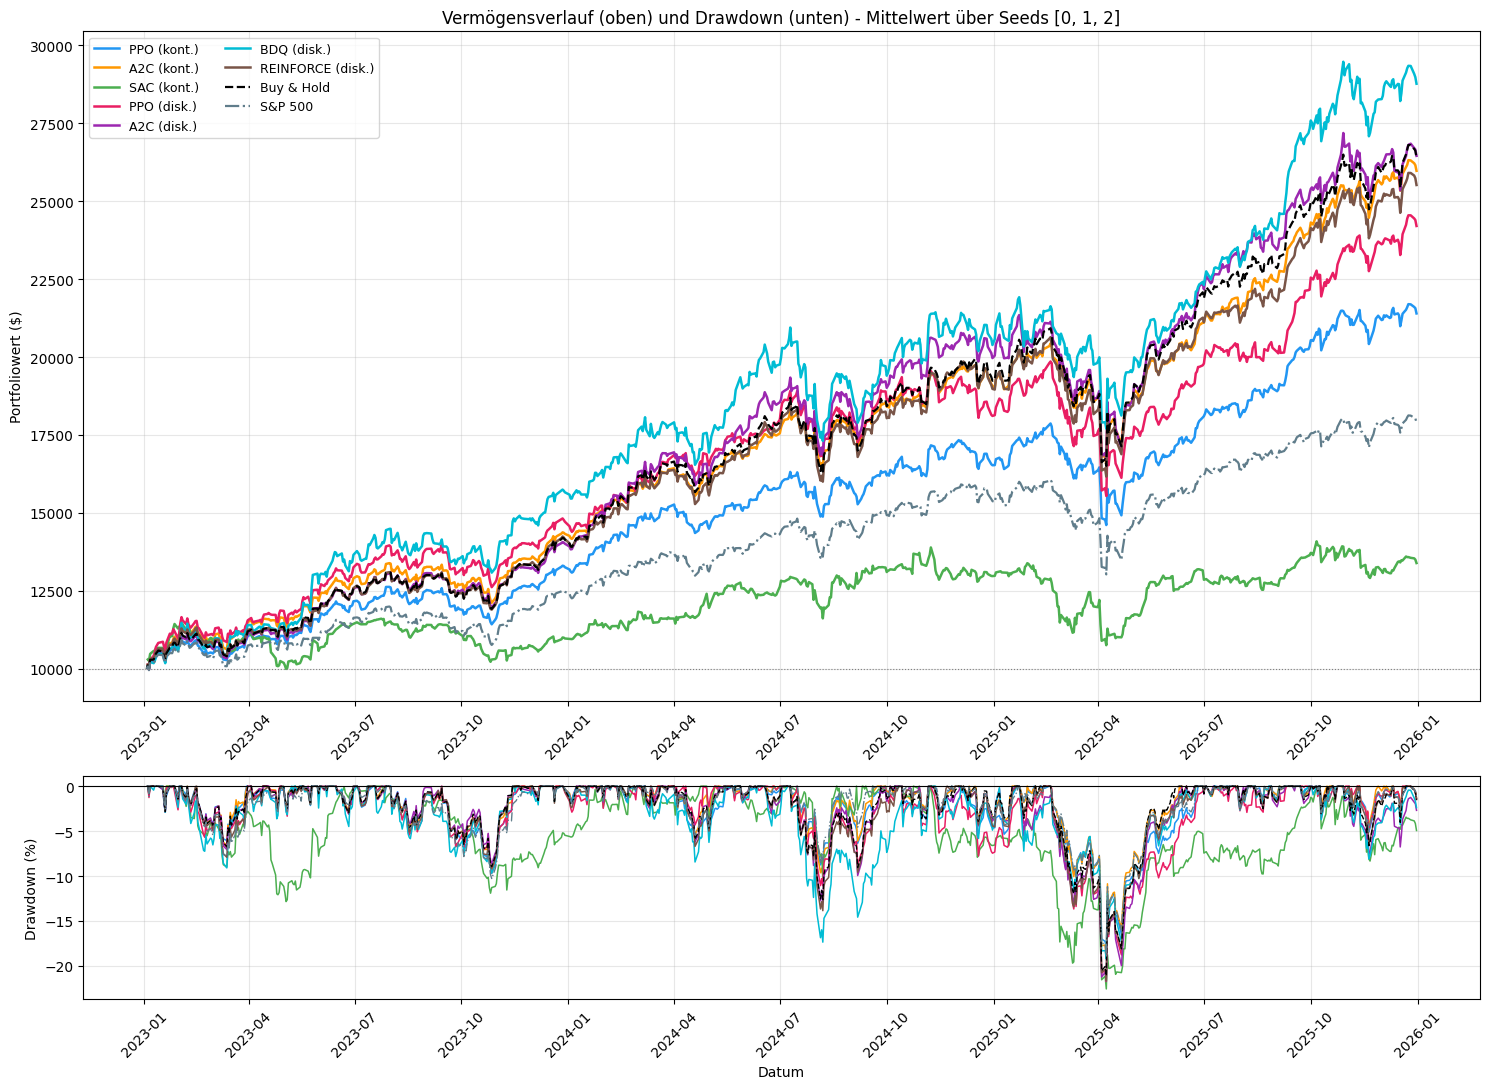

Saved /content/drive/MyDrive/TradingAgent/plots/evaluation_all_models.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================================
#  Figure: portfolio value (top) and running drawdown (bottom) over the test
#  period. Each agent is drawn as the mean curve across the three seeds (clean
#  lines, no shaded band). The seed-to-seed spread is reported numerically as
#  mean +/- std in the result tables (tab:results_all, tab:turnover).
#  Saved as evaluation_all_models.png
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

PLOT_ORDER = [
    ("ppo_cont",   "PPO (kont.)",       "#2196F3"),
    ("a2c_cont",   "A2C (kont.)",       "#FF9800"),
    ("sac_cont",   "SAC (kont.)",       "#4CAF50"),
    ("ppo_disc",   "PPO (disk.)",       "#E91E63"),
    ("a2c_disc",   "A2C (disk.)",       "#9C27B0"),
    ("bdq_disc",   "BDQ (disk.)",       "#00BCD4"),
    ("reinf_disc", "REINFORCE (disk.)", "#795548"),
]


def _load_mean(key):
    """Return the mean portfolio-value curve across seeds, or None."""
    curves = []
    for seed in SEEDS:
        path = f"{RESULTS_DIR}/curve_{key}_seed{seed}.csv"
        if not os.path.exists(path):
            continue
        c = pd.read_csv(path, parse_dates=["date"]).set_index("date")["portfolio_value"]
        curves.append(c)
    if not curves:
        return None
    return pd.concat(curves, axis=1).mean(axis=1)


def _drawdown(series):
    pv   = series.values
    peak = np.maximum.accumulate(pv)
    return pd.Series((pv - peak) / (peak + 1e-9) * 100.0, index=series.index)


fig, axes = plt.subplots(2, 1, figsize=(15, 11),
                         gridspec_kw={"height_ratios": [3, 1]})
ax, ax2 = axes

for key, label, color in PLOT_ORDER:
    mean = _load_mean(key)
    if mean is None:
        continue
    ax.plot(mean.index, mean.values, label=label, color=color, linewidth=1.8)
    ax2.plot(mean.index, _drawdown(mean).values, color=color, linewidth=1.1)

# Buy & Hold baseline (single deterministic curve)
bah_path = f"{RESULTS_DIR}/curve_buyhold.csv"
if os.path.exists(bah_path):
    b = pd.read_csv(bah_path, parse_dates=["date"]).set_index("date")["portfolio_value"]
    ax.plot(b.index, b.values, label="Buy & Hold", color="#000000",
            linewidth=1.6, linestyle="--")
    ax2.plot(b.index, _drawdown(b).values, color="#000000",
             linewidth=1.0, linestyle="--")

# S&P 500 baseline (single deterministic curve)
sp_path = f"{RESULTS_DIR}/curve_sp500.csv"
if os.path.exists(sp_path):
    sp = pd.read_csv(sp_path, parse_dates=["date"]).set_index("date")["portfolio_value"]
    ax.plot(sp.index, sp.values, label="S&P 500", color="#607D8B",
            linewidth=1.6, linestyle="-.")
    ax2.plot(sp.index, _drawdown(sp).values, color="#607D8B",
             linewidth=1.0, linestyle="-.")

ax.set_title("Vermögensverlauf (oben) und Drawdown (unten) - Mittelwert über Seeds "
             + str(SEEDS))
ax.set_ylabel("Portfoliowert ($)")
ax.axhline(10_000, color="grey", linewidth=0.8, linestyle=":")
ax.legend(ncol=2, fontsize=9, loc="upper left")
ax.grid(alpha=0.3)

ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Datum")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.grid(alpha=0.3)

for a in (ax, ax2):
    a.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(a.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
out = f"{PLOTS_DIR}/evaluation_all_models.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out}")


# 6 - Learning Curves

To check that the training budget of `TIMESTEPS = 1_000_000` steps per seed is sufficient, the cell below plots the **learning curve** of every agent: the average training episode return (sum of daily log-returns over a 504-day training episode) against the number of training timesteps, averaged over the seeds `{0, 1, 2}`.

The reading is simple:

- if a curve **flattens** well before 1M steps, that agent has converged and the budget is more than enough;
- if a curve is **still rising** at 1M steps, that agent is under-trained and the budget (or the learning rate) should be revisited *before* drawing conclusions from its test-period results.

The curves are reconstructed from `results/learncurve_<agent>_seed<seed>.csv`, which the driver writes during training.


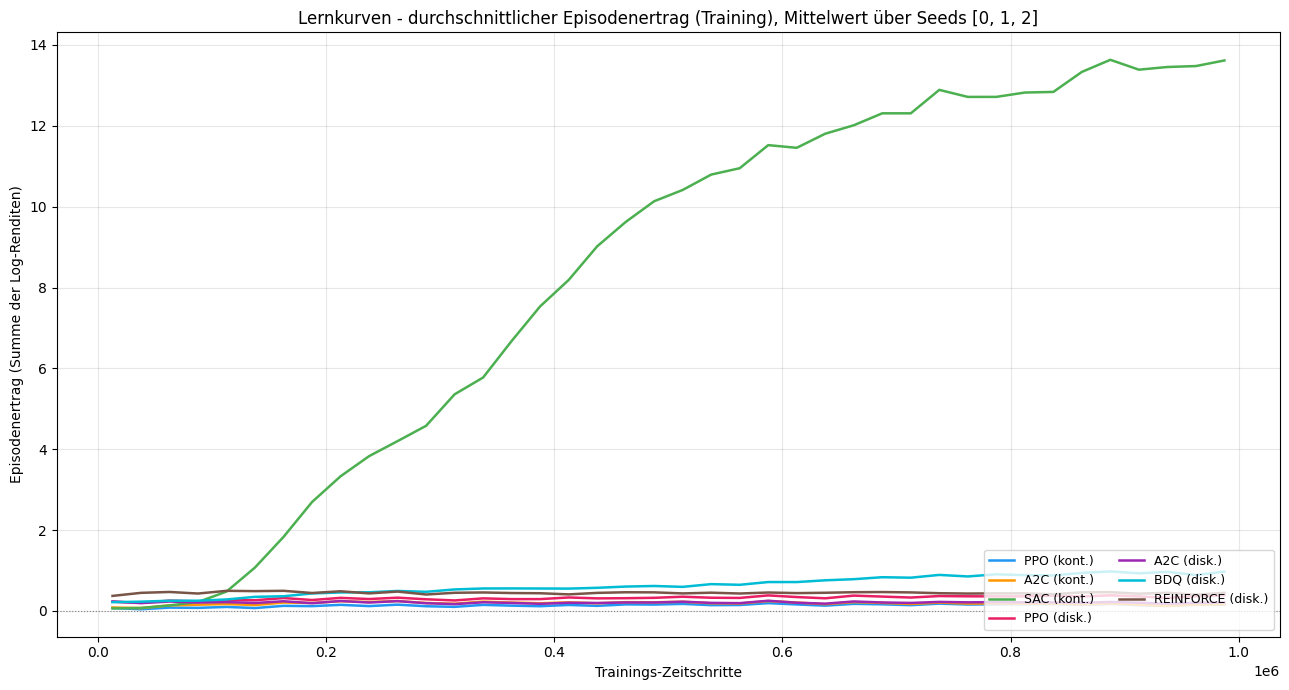

Saved /content/drive/MyDrive/TradingAgent/plots/learning_curves.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================================
#  Learning-curve figure: mean training episode return vs. timesteps.
#  Pools all seeds and bins by timestep, so each agent shows one smooth mean
#  curve. A curve that flattens before TIMESTEPS demonstrates convergence and
#  justifies the chosen training budget.
#  Saved as learning_curves.png
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LC_ORDER = [
    ("ppo_cont",   "PPO (kont.)",       "#2196F3"),
    ("a2c_cont",   "A2C (kont.)",       "#FF9800"),
    ("sac_cont",   "SAC (kont.)",       "#4CAF50"),
    ("ppo_disc",   "PPO (disk.)",       "#E91E63"),
    ("a2c_disc",   "A2C (disk.)",       "#9C27B0"),
    ("bdq_disc",   "BDQ (disk.)",       "#00BCD4"),
    ("reinf_disc", "REINFORCE (disk.)", "#795548"),
]

N_BINS  = 40
edges   = np.linspace(0, TIMESTEPS, N_BINS + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, ax = plt.subplots(figsize=(13, 7))

for key, label, color in LC_ORDER:
    frames = []
    for seed in SEEDS:
        p = f"{RESULTS_DIR}/learncurve_{key}_seed{seed}.csv"
        if os.path.exists(p):
            frames.append(pd.read_csv(p))
    if not frames:
        continue
    df = pd.concat(frames, ignore_index=True)
    # Bin episodes by timestep and average the return within each bin (pools seeds)
    bin_idx = np.clip(np.digitize(df["timestep"].to_numpy(), edges) - 1, 0, N_BINS - 1)
    df = df.assign(_bin=bin_idx)
    binned = df.groupby("_bin")["ep_return"].mean()
    ax.plot(centers[binned.index.to_numpy()], binned.to_numpy(),
            label=label, color=color, linewidth=1.8)

ax.set_title("Lernkurven - durchschnittlicher Episodenertrag (Training), "
             "Mittelwert über Seeds " + str(SEEDS))
ax.set_xlabel("Trainings-Zeitschritte")
ax.set_ylabel("Episodenertrag (Summe der Log-Renditen)")
ax.axhline(0.0, color="grey", linewidth=0.8, linestyle=":")
ax.legend(ncol=2, fontsize=9, loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
out = f"{PLOTS_DIR}/learning_curves.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out}")
